In [69]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [70]:
class Batsmanstate(TypedDict):
    runs:int
    balls:int
    fours:int
    sixes:int

    sr:float
    bpb:float
    boundary_percent:float
    summary: str

In [71]:
def cal_sr(state:Batsmanstate):
    sr= (state['runs']/state['balls'])*100

    return {'sr':sr}

In [72]:
def cal_bpb(state:Batsmanstate):
    bpb=state['balls']/(state['fours']+state['sixes'])

    return {'bpb':bpb}

In [73]:
def cal_boundery_percentage(state:Batsmanstate):

    boundary_percent=(((state['fours']*4 )+(state['sixes']*6))/state['runs'])*100

    return {'boundary_percent': boundary_percent}

In [74]:
def summary(state:Batsmanstate):

    summary = f"""
Strike Rate - {state['sr']} \n
Balls per boundary - {state['bpb']} \n
Boundary percent - {state['boundary_percent']}
"""
    
    return {'summary': summary}

In [75]:
graph =StateGraph(Batsmanstate)
graph.add_node('cal_sr',cal_sr)
graph.add_node('cal_bpb',cal_bpb)
graph.add_node('cal_boundery_per',cal_boundery_percentage)
graph.add_node('summary', summary)

graph.add_edge(START, 'cal_sr')
graph.add_edge(START, 'cal_bpb')
graph.add_edge(START, 'cal_boundery_per')

graph.add_edge('cal_sr', 'summary')
graph.add_edge('cal_bpb', 'summary')
graph.add_edge('cal_boundery_per', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()

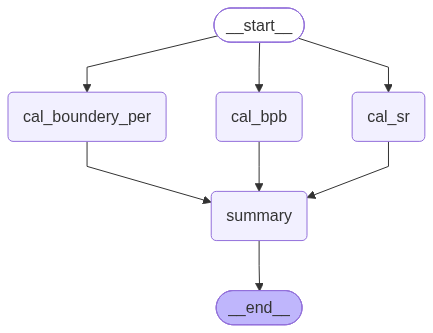

In [76]:
workflow

In [77]:
initial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

final_state = workflow.invoke(initial_state)

print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 5.0, 'boundary_percent': 48.0, 'summary': '\nStrike Rate - 200.0 \n\nBalls per boundary - 5.0 \n\nBoundary percent - 48.0\n'}
